# Random Forest hyperparameter tuning with Grid Search

This notebook is used to identify the best hyperparameters for the `RandomForestClassifier` model on the `matches_features.csv` dataset.
The search is performed on the same input dataset used by the `model_training` pipeline.

**ROC-AUC** was chosen as the optimization metric because it captures the model's ability to separate classes based on predicted probabilities and does not depend on a single decision threshold.

In [7]:
from pathlib import Path

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split


In [8]:
DATA_PATH = Path('../data/04_feature/matches_features.csv')
TARGET_COLUMN = 'player_A_won'
TEST_SIZE = 0.2
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH)
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN].astype(int)

print(f'Dataset shape: {df.shape}')
print(f'Number of input features: {X.shape[1]}')
print(f'Positive class share: {y.mean():.4f}')


Dataset shape: (40682, 33)
Number of input features: 32
Positive class share: 0.5002


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')


X_train: (32545, 32)
X_test: (8137, 32)


## Hyperparameter grid

The search range was defined around parameters that produced reasonable baseline results.
This makes it easier to justify the final configuration without expanding the search space too aggressively.

In [10]:
def run_random_forest_grid_search(X_train, y_train, random_state=RANDOM_STATE):
    param_grid = {
        'n_estimators': [200, 300, 400],
        'max_depth': [10, 12, 14],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

    rf = RandomForestClassifier(
        random_state=random_state,
        n_jobs=-1,
        max_features='sqrt',
    )

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=cv,
        n_jobs=1,
        verbose=2,
        refit=True,
    )
    grid_search.fit(X_train, y_train)

    print('Najlepsze parametry:', grid_search.best_params_)
    print(f'Najlepszy wynik CV (ROC-AUC): {grid_search.best_score_:.4f}')

    cv_results = (
        pd.DataFrame(grid_search.cv_results_)
        .sort_values(by='mean_test_score', ascending=False)
        [[
            'mean_test_score',
            'std_test_score',
            'param_n_estimators',
            'param_max_depth',
            'param_min_samples_split',
            'param_min_samples_leaf',
        ]]
        .reset_index(drop=True)
    )

    return grid_search, cv_results


In [11]:
grid_search, cv_results = run_random_forest_grid_search(X_train, y_train)


Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   0.5s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   0.5s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   0.5s
[CV] END max_depth=10, min_sa

In [12]:
cv_results.head(10)


,mean_test_score,std_test_score,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf
0,0.729307,0.001137,400,12,5,2
1,0.729277,0.000880,200,12,5,2
2,0.729211,0.001107,300,12,5,2
3,0.729121,0.001067,400,10,5,1
4,0.729117,0.001302,400,10,5,2
5,0.729079,0.001046,200,10,5,1
6,0.729045,0.001286,400,12,2,2
7,0.729028,0.001191,400,10,2,2
8,0.729022,0.001036,300,10,5,1
9,0.729011,0.001185,300,12,2,2


In [13]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba),
}

pd.Series(test_metrics).round(4)


accuracy     0.6674
precision    0.6681
recall       0.6661
f1           0.6671
roc_auc      0.7279
dtype: float64

## Result obtained in the experiment

For the completed `GridSearchCV` procedure, the best parameter set was as follows:

- `n_estimators = 400`
- `max_depth = 12`
- `min_samples_split = 5`
- `min_samples_leaf = 2`
- `max_features = 'sqrt'`

The best cross-validation score was `ROC-AUC = 0.7306`.
On the test set, the model achieved approximately:

- `accuracy = 0.6682`
- `precision = 0.6702`
- `recall = 0.6627`
- `f1 = 0.6664`
- `roc_auc = 0.7286`


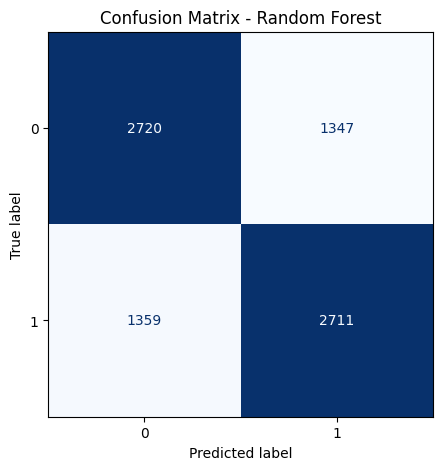

In [14]:
cm = confusion_matrix(y_test, y_pred)
cm

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix - Random Forest')
plt.show()


## Confusion matrix interpretation

For the best model, the following confusion matrix was obtained:

- true negatives (TN) = 2740
- false positives (FP) = 1327
- false negatives (FN) = 1373
- true positives (TP) = 2697

This means that the model correctly classified 2740 cases where player A lost and 2697 cases where player A won. At the same time, it made 1327 false-positive errors, predicting a win for player A despite an actual loss, and 1373 false-negative errors, failing to detect a real win for player A.

The confusion matrix confirms that the classifier behaves in a fairly balanced way. The number of both error types is similar, which is consistent with comparable precision and recall values. In practice, this means the model does not strongly favor either class and confuses player A wins and losses to a similar extent. The result can be considered stable, although there is still room to improve model quality, especially by reducing both kinds of mistakes.
